<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/carte_illumination_satellites.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛰️ Carte alt-az d'illumination des satellites — planification hors-ligne

Cet outil trace, pour **n'importe quel lieu, date et heure**, la carte du ciel indiquant
les régions où un satellite serait **éclairé par le Soleil** (donc traçant sur vos poses)
et celles qui sont déjà dans **l'ombre de la Terre** (donc propres).

**Aucune donnée orbitale (TLE) n'est nécessaire** : le calcul est purement géométrique.

## Principe

Un satellite ne laisse une trace que s'il est éclairé par le Soleil pendant que l'observateur
est dans le noir. Dès qu'il entre dans le cône d'ombre de la Terre, il disparaît.
Pour un satellite au **zénith** à l'altitude $h$, l'entrée dans l'ombre (modèle cylindrique)
se produit quand la dépression solaire $\beta$ dépasse :

$$\beta > \arccos\!\left(\frac{R_\oplus}{R_\oplus+h}\right)$$

| Coquille | Altitude | Seuil $\beta$ au zénith |
|---|---|---|
| Coquilles basses | ~340 km | **18°** |
| Starlink | ~550 km | **23°** |
| OneWeb | ~1200 km | **33°** |

Deux conséquences : la **calotte anti-solaire** (à l'opposé du Soleil) s'éteint la première ;
la zone qui reste polluée le plus longtemps est **haute et vers l'azimut du Soleil**.
À la latitude de Toulouse (~43,6°), l'été le Soleil ne descend qu'à ~−23° : les nuits d'été
restent largement polluées ; l'hiver ($\beta$ jusqu'à ~70°) offre des heures de ciel propre.

> Hypothèses : ombre cylindrique (pénombre et taille angulaire du Soleil négligées ⇒ précision
> ~0,25° sur $\beta$) ; Terre sphérique $R_\oplus=6371$ km ; réfraction ignorée près de l'horizon.
> C'est une carte de *possibilité géométrique* d'illumination, indépendante du nombre réel de
> satellites présents dans chaque direction (pour ça → propagation SGP4 / SatChecker / Astrosat).

In [1]:
# Colab a deja tout ; filet de securite
!pip -q install astropy matplotlib >/dev/null 2>&1
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
from astropy.coordinates import EarthLocation, AltAz, get_sun, SkyCoord
from astropy.time import Time
import astropy.units as u
import warnings; warnings.filterwarnings("ignore")

R_EARTH = 6371.0  # km

In [2]:
# ---------------------------------------------------------------------------
#  Fonctions coeur
# ---------------------------------------------------------------------------
def local_to_utc(y, mo, d, h, mi, tz="Europe/Paris"):
    """Datetime local (avec heure d'ete/hiver geree) -> astropy.Time UTC."""
    dt = datetime(y, mo, d, h, mi, tzinfo=ZoneInfo(tz)).astimezone(ZoneInfo("UTC"))
    return Time(dt)

def sun_altaz(t, loc):
    """Altitude et azimut apparents du Soleil (deg) pour un instant et un lieu."""
    s = get_sun(t).transform_to(AltAz(obstime=t, location=loc))
    return float(s.alt.deg), float(s.az.deg)

def is_sunlit(alt_deg, az_deg, sun_alt_deg, sun_az_deg, h_km, R=R_EARTH):
    """True si un satellite vu en (alt,az) a l'altitude de coquille h_km est
    eclaire par le Soleil (hors ombre cylindrique de la Terre).
    Vectorise : alt_deg/az_deg peuvent etre des tableaux numpy."""
    alt = np.radians(alt_deg); az = np.radians(az_deg)
    sa  = np.radians(sun_alt_deg); saz = np.radians(sun_az_deg)
    # direction de visee dans le repere local ENU (Est, Nord, Haut)
    d = np.stack([np.cos(alt)*np.sin(az), np.cos(alt)*np.cos(az), np.sin(alt)], axis=-1)
    O = np.array([0., 0., R])                      # observateur (sur une Terre spherique)
    shat = np.array([np.cos(sa)*np.sin(saz),       # direction du Soleil (unitaire)
                     np.cos(sa)*np.cos(saz), np.sin(sa)])
    # distance oblique jusqu'a la coquille : s^2 + 2R sin(alt) s + (R^2-(R+h)^2)=0
    b = 2.*R*np.sin(alt); c = R**2 - (R+h_km)**2
    s = (-b + np.sqrt(b**2 - 4*c)) / 2.
    P = O + s[..., None]*d                          # position geocentrique du satellite
    proj = P @ shat                                 # projection sur l'axe Terre-Soleil
    perp = np.sqrt(np.maximum(np.sum(P*P, axis=-1) - proj**2, 0.))
    in_shadow = (proj < 0) & (perp < R)             # derriere la Terre ET dans le cylindre
    return ~in_shadow

def beta_seuil(h_km, R=R_EARTH):
    """Depression solaire (deg) d'extinction au zenith pour la coquille h_km."""
    return np.degrees(np.arccos(R/(R+h_km)))

print("Seuils au zenith :",
      {h: round(beta_seuil(h),1) for h in (340, 550, 1200)})

Seuils au zenith : {340: np.float64(18.3), 550: np.float64(23.0), 1200: np.float64(32.7)}


In [4]:
# ---------------------------------------------------------------------------
#  PARAMETRES  --  a modifier
# ---------------------------------------------------------------------------
LAT, LON, HEIGHT = 43.61, 1.33, 180        # Colomiers (deg, deg, m)
TZ               = "Europe/Paris"
YEAR, MONTH, DAY = 2026, 7, 8              # date locale
HOUR, MINUTE     = 2, 00                   # heure locale
SHELL_KM         = 550                     # 340 / 550 (Starlink) / 1200 (OneWeb)
MIN_ALT          = 20                      # hauteur mini exploitable (deg)

loc = EarthLocation(lat=LAT*u.deg, lon=LON*u.deg, height=HEIGHT*u.m)
t   = local_to_utc(YEAR, MONTH, DAY, HOUR, MINUTE, TZ)
sun_alt, sun_az = sun_altaz(t, loc)
print(f"{DAY:02d}/{MONTH:02d}/{YEAR} {HOUR:02d}:{MINUTE:02d} {TZ}")
print(f"Soleil : altitude {sun_alt:+.2f} deg  (depression {-sun_alt:.2f} deg), azimut {sun_az:.1f} deg")
print(f"Coquille {SHELL_KM} km : seuil zenith = {beta_seuil(SHELL_KM):.1f} deg")

08/07/2026 02:00 Europe/Paris
Soleil : altitude -23.90 deg  (depression 23.90 deg), azimut 0.1 deg
Coquille 550 km : seuil zenith = 23.0 deg


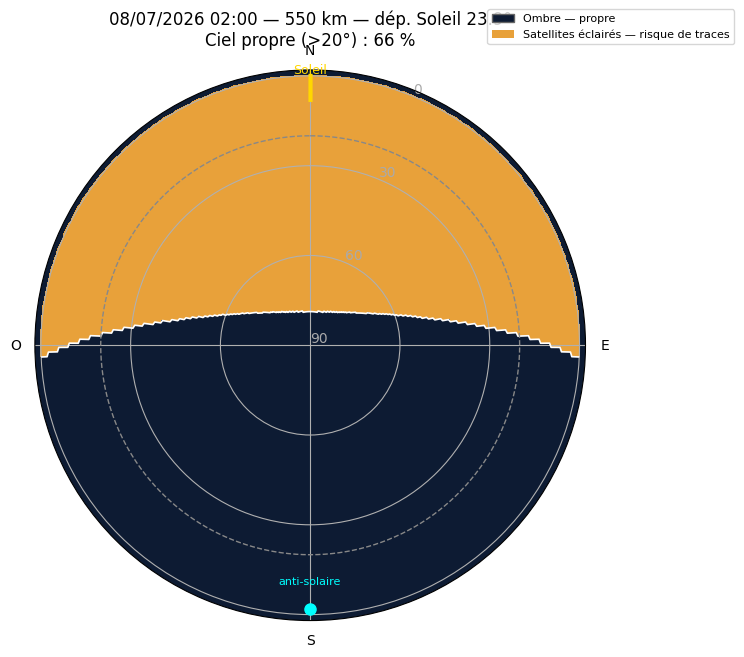

In [5]:
# ---------------------------------------------------------------------------
#  CARTE ALL-SKY d'illumination
# ---------------------------------------------------------------------------
def carte_allsky(sun_alt, sun_az, h_km, min_alt=MIN_ALT, titre=""):
    alt = np.arange(0, 90.001, 0.5)
    az  = np.arange(0, 360.001, 1.0)
    AZ, ALT = np.meshgrid(az, alt)
    lit = is_sunlit(ALT, AZ, sun_alt, sun_az, h_km).astype(float)   # 1=eclaire, 0=ombre

    m = ALT >= min_alt
    frac = 100.0 * np.mean(~is_sunlit(ALT[m], AZ[m], sun_alt, sun_az, h_km).astype(bool))

    fig = plt.figure(figsize=(7.6, 7.6))
    ax = fig.add_subplot(111, polar=True)
    ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)
    cmap = ListedColormap(["#0d1b33", "#e8a13a"])   # ombre (propre) / eclaire (risque)
    ax.pcolormesh(np.radians(AZ), 90-ALT, lit, cmap=cmap, shading='auto', vmin=0, vmax=1)
    # terminateur d'ombre
    ax.contour(np.radians(AZ), 90-ALT, lit, levels=[0.5], colors='white', linewidths=1.2)
    # anneau de hauteur mini exploitable
    th = np.radians(np.linspace(0, 360, 361))
    ax.plot(th, np.full_like(th, 90-min_alt), '--', color='#888', lw=1)
    # Soleil (sous l'horizon) et point anti-solaire
    ax.plot([np.radians(sun_az)]*2, [82, 90], color='gold', lw=3)
    ax.annotate("Soleil", (np.radians(sun_az), 92), color='gold',
                ha='center', va='center', fontsize=9)
    ax.plot(np.radians((sun_az+180) % 360), 88, 'o', color='cyan', ms=8)
    ax.annotate("anti-solaire", (np.radians((sun_az+180) % 360), 80),
                color='cyan', ha='center', fontsize=8)

    ax.set_rlim(0, 92); ax.set_rticks([0, 30, 60, 90])
    ax.set_yticklabels(['90', '60', '30', '0'], color='#aaa')
    ax.set_thetagrids([0, 90, 180, 270], labels=['N', 'E', 'S', 'O'])
    ax.set_facecolor('#0d1b33')
    ax.set_title(f"{titre}\nCiel propre (>{min_alt}°) : {frac:.0f} %",
                 pad=18, fontsize=12)
    leg = [Patch(fc="#0d1b33", ec='#666', label="Ombre — propre"),
           Patch(fc="#e8a13a", label="Satellites éclairés — risque de traces")]
    ax.legend(handles=leg, loc='upper right', bbox_to_anchor=(1.28, 1.12), fontsize=8)
    plt.tight_layout(); plt.show()
    return frac

titre = f"{DAY:02d}/{MONTH:02d}/{YEAR} {HOUR:02d}:{MINUTE:02d} — {SHELL_KM} km — dép. Soleil {-sun_alt:.1f}°"
_ = carte_allsky(sun_alt, sun_az, SHELL_KM, MIN_ALT, titre)

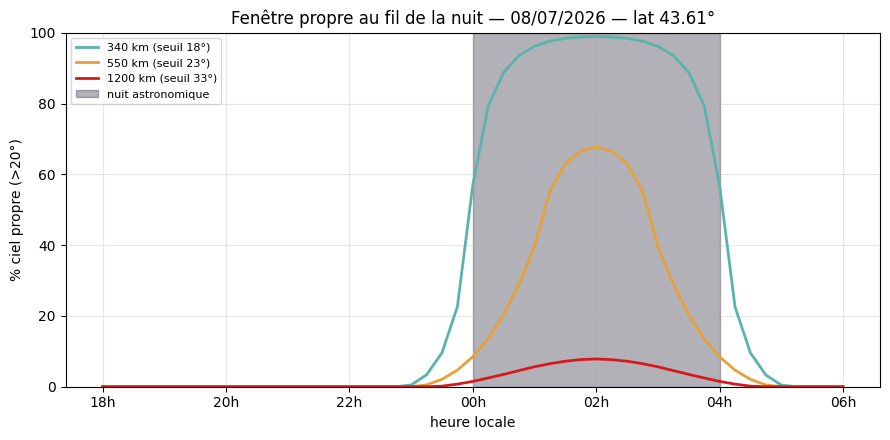

In [6]:
# ---------------------------------------------------------------------------
#  EVOLUTION SUR LA NUIT : fraction de ciel propre vs heure locale
# ---------------------------------------------------------------------------
t0 = local_to_utc(YEAR, MONTH, DAY, 18, 0, TZ)
times = [t0 + timedelta(minutes=15*i) for i in range(49)]   # 18h -> 6h, pas 15 min
xh    = [18 + 0.25*i for i in range(49)]                    # heure locale decimale

alt = np.arange(0, 90.001, 1.0); az = np.arange(0, 360.001, 2.0)
AZ, ALT = np.meshgrid(az, alt); m = ALT >= MIN_ALT

fig, ax = plt.subplots(figsize=(9, 4.5))
sun_deps = []
for h_km, col in [(340, '#5ab4ac'), (550, '#e8a13a'), (1200, '#d7191c')]:
    frac = []
    for tt in times:
        sa, sz = sun_altaz(tt, loc)
        sun_deps.append(-sa)
        frac.append(100*np.mean(~is_sunlit(ALT[m], AZ[m], sa, sz, h_km).astype(bool))
                    if sa < 0 else 0.0)
    ax.plot(xh, frac, color=col, lw=2, label=f"{h_km} km (seuil {beta_seuil(h_km):.0f}°)")

# nuit astronomique (Soleil < -18 deg)
deps = np.array([-sun_altaz(tt, loc)[0] for tt in times])
night = deps > 18
ax.fill_between(xh, 0, 100, where=night, color='#223', alpha=0.35,
                label="nuit astronomique", step='mid')
ax.set_xlabel("heure locale"); ax.set_ylabel(f"% ciel propre (>{MIN_ALT}°)")
ax.set_xticks(range(18, 31, 2)); ax.set_xticklabels([f"{h%24:02d}h" for h in range(18, 31, 2)])
ax.set_ylim(0, 100); ax.grid(alpha=0.3)
ax.set_title(f"Fenêtre propre au fil de la nuit — {DAY:02d}/{MONTH:02d}/{YEAR} — lat {LAT}°")
ax.legend(fontsize=8, loc='upper left'); plt.tight_layout(); plt.show()

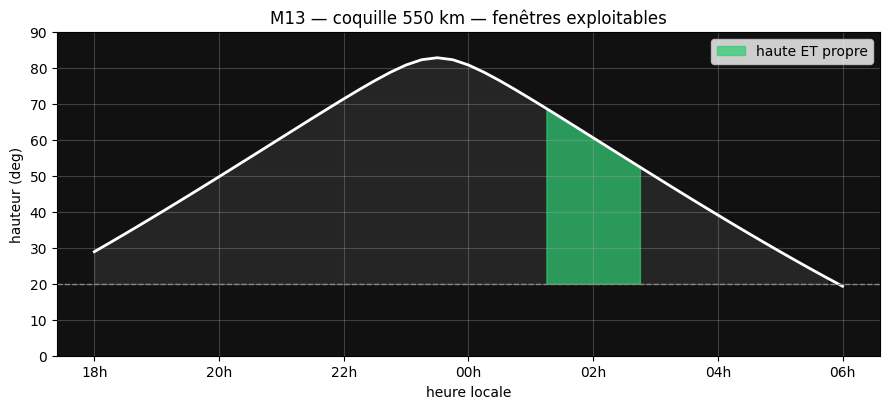

Fenêtres propres :
  01h15 -> 02h45


In [7]:
# ---------------------------------------------------------------------------
#  PLANIFICATION D'UNE CIBLE : quand est-elle a la fois haute ET propre ?
# ---------------------------------------------------------------------------
# Option A : par nom (necessite le reseau, ex. "M57", "NGC 2024", "P Cyg")
# Option B : par coordonnees RA/Dec en degres
TARGET_NAME = "M13"          # None pour utiliser RA/DEC ci-dessous
RA_DEG, DEC_DEG = 250.4, 36.5

try:
    cible = SkyCoord.from_name(TARGET_NAME) if TARGET_NAME else SkyCoord(RA_DEG*u.deg, DEC_DEG*u.deg)
    nom = TARGET_NAME or f"RA={RA_DEG} Dec={DEC_DEG}"
except Exception as e:
    print("from_name indisponible, on utilise RA/DEC :", e)
    cible = SkyCoord(RA_DEG*u.deg, DEC_DEG*u.deg); nom = f"RA={RA_DEG} Dec={DEC_DEG}"

alts, propres = [], []
for tt in times:
    sa, sz = sun_altaz(tt, loc)
    aa = cible.transform_to(AltAz(obstime=tt, location=loc))
    a = float(aa.alt.deg)
    alts.append(a)
    clean = (a > MIN_ALT) and (sa < 0) and (not is_sunlit(np.array([a]), np.array([float(aa.az.deg)]), sa, sz, SHELL_KM)[0])
    propres.append(clean)

alts = np.array(alts); propres = np.array(propres); xh_a = np.array(xh)
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(xh_a, alts, color='w', lw=2)
ax.fill_between(xh_a, MIN_ALT, alts, where=(alts > MIN_ALT), color='#444', alpha=0.4)
ax.fill_between(xh_a, MIN_ALT, alts, where=propres & (alts > MIN_ALT),
                color='#2ecc71', alpha=0.7, label="haute ET propre")
ax.axhline(MIN_ALT, color='#888', ls='--', lw=1)
ax.set_xticks(range(18, 31, 2)); ax.set_xticklabels([f"{h%24:02d}h" for h in range(18, 31, 2)])
ax.set_xlabel("heure locale"); ax.set_ylabel("hauteur (deg)")
ax.set_ylim(0, 90); ax.grid(alpha=0.3); ax.set_facecolor('#111')
ax.set_title(f"{nom} — coquille {SHELL_KM} km — fenêtres exploitables")
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

# resume texte des fenetres propres
idx = np.where(propres)[0]
if len(idx):
    seg = np.split(idx, np.where(np.diff(idx) > 1)[0]+1)
    print("Fenêtres propres :")
    for s in seg:
        print(f"  {int(xh[s[0]])%24:02d}h{int((xh[s[0]]%1)*60):02d} "
              f"-> {int(xh[s[-1]])%24:02d}h{int((xh[s[-1]]%1)*60):02d}")
else:
    print("Aucune fenêtre propre cette nuit pour cette cible / coquille.")

## Limites & extension

- **Modèle géométrique** : c'est une carte de *possibilité d'illumination*, pas un comptage de
  satellites réels. Une direction « propre » peut encore recevoir un objet plus haut (OneWeb à
  1200 km) ou un débris ; une direction « éclairée » ne sera traversée que s'il y a effectivement
  un satellite qui y passe.
- **Ombre cylindrique** : pénombre et diamètre angulaire du Soleil négligés (~0,25° d'incertitude
  sur $\beta$), réfraction atmosphérique ignorée près de l'horizon.
- **Glints/flares** spéculaires : imprévisibles, non couverts par ce modèle.
- **Spectro à fente** : bien moins sensible que l'imagerie grand champ — une pose contaminée
  parmi une série se rejette facilement.

**Pour passer aux traces réelles** : propager des TLE avec `skyfield` (SGP4) sur un catalogue
Celestrak, appliquer `is_sunlit` à chaque satellite, et compter les traversées par direction →
heatmap de densité réelle. Voir aussi l'API **SatChecker** (IAU SatHub) et **Astrosat** (MNRAS).
Note : le format TLE doit être déprécié vers juillet 2026 (bascule CSV/JSON/KVN).